# Analysis of mirror codes
This is a high-level wrapper of the mirror code and benchmarking functionalities of this repository, enabling benchmarking of a chosen mirror code.

In [8]:
from mirror import MirrorCode
from benchmark import StabilizerCode, make_noise_model
import numpy as np
import matplotlib.pyplot as plt
import stim
import sinter
from tesseract_decoder import make_tesseract_sinter_decoders_dict, TesseractSinterDecoder
import tesseract_decoder

# Set up tesseract to interact with sinter for decoding in parallel
decoders = ['tesseract', 'tesseract-long-beam', 'tesseract-short-beam']
decoder_dict = make_tesseract_sinter_decoders_dict()
# You can also make your own custom Tesseract Decoder to-be-used with Sinter.
decoders.append('custom-tesseract-decoder')
decoder_dict['custom-tesseract-decoder'] = TesseractSinterDecoder(
    det_beam=10,
    beam_climbing=True,
    no_revisit_dets=True,
    merge_errors=True,
    pqlimit=1_000,
    num_det_orders=5,
    det_order_method=tesseract_decoder.utils.DetOrder.DetIndex,
    seed=2384753,
)
decoders = ['tesseract']

As an example, let us benchmark the `[[n, k, d, w]] = [[36, 6, 6, 6]]` code.

In [15]:
# [[36, 6, 6, 6]] code
code = MirrorCode(
        group = [2, 2, 3, 3],
        z0 = [[0, 0, 0, 0],
       [0, 1, 0, 1],
       [1, 0, 0, 2]],
        x0 = [[0, 0, 0, 0],
       [0, 1, 1, 0],
       [1, 1, 2, 0]]
    )

CODE_NAME = "[[36, 6, 6]]"
NOISE_MODEL_NAME = "SI1000"

In [ ]:
print("Finding stabilizers...")
stabilizers = code.get_stim_tableau()
print("Done.")

benchmarker = StabilizerCode(stabilizers, verbose=False, name=CODE_NAME)

T = 6 # min error rate is 10^-T
NUM_PROBS = 4

# Define the main parameters of the benchmarking
ROUND_CHOICES = [3]
PS = np.logspace(-T, -2, NUM_PROBS)
NUM_SHOTS = 1000

SECS = [code.bare_ancilla_sec(noise=make_noise_model(PS[i], NOISE_MODEL_NAME),
                              num_rounds=nrd
                              )
                            for nrd in ROUND_CHOICES
                            for i in range(len(PS))
        ]


Finding stabilizers...
Done.


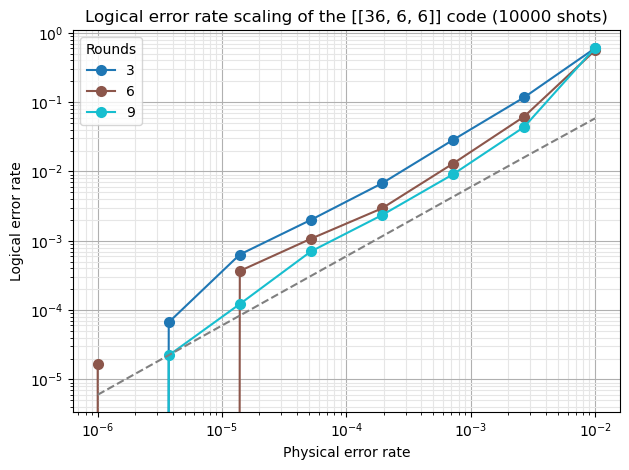

In [4]:
phys_rate, log_rate = benchmarker.parallel_benchmark(ps=PS,
                               secs=SECS,
                               rounds_choices=ROUND_CHOICES,
                               num_shots=NUM_SHOTS,
                               plot=True
                               )

In [ ]:
tasks = []

for decoder in decoders:
    for i in range(NUM_PROBS):
        for nrd in ROUND_CHOICES:
            circuit = code.bare_ancilla_sec(
                                noise=make_noise_model(PS[i], NOISE_MODEL_NAME),
                                num_rounds=nrd
                                )
            tasks.append(sinter.Task(
                circuit=circuit,
                decoder=decoder,
                json_metadata={"p": PS[i], "decoder": decoder, "rounds": nrd},
            ))

In [11]:
# Collect decoding outcomes per task from Sinter.
results = sinter.collect(
    num_workers=8,
    tasks=tasks,
    max_shots=10_000,
    decoders=decoders,
    custom_decoders=decoder_dict,
    print_progress=True,
)

Starting 8 workers...
4 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                      
        2 tesseract <1m       5631           1 p=1e-06,decoder=tesseract,rounds=3                 
        2 tesseract   ?      10000           0 p=2.1544346900318823e-05,decoder=tesseract,rounds=3
        2 tesseract   ?      10000           0 p=0.00046415888336127773,decoder=tesseract,rounds=3
        2 tesseract   ?      10000           0 p=0.01,decoder=tesseract,rounds=3                  
3 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                      
        3 tesseract <1m       1786          14 p=2.1544346900318823e-05,decoder=tesseract,rounds=3
        3 tesseract <1m       9454          21 p=0.00046415888336127773,decoder=tesseract,rounds=3
        2 tesseract  6m       9999           1 p=0.01,decoder=tesseract,rounds=3                  


2 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                      
        4 tesseract <1m       9454          21 p=0.00046415888336127773,decoder=tesseract,rounds=3
        4 tesseract  5m       9998           2 p=0.01,decoder=tesseract,rounds=3                  
2 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                      
        4 tesseract <1m       9181          41 p=0.00046415888336127773,decoder=tesseract,rounds=3
        4 tesseract  5m       9998           2 p=0.01,decoder=tesseract,rounds=3                  


2 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                      
        4 tesseract <1m       6860         154 p=0.00046415888336127773,decoder=tesseract,rounds=3
        4 tesseract  4m       9994           6 p=0.01,decoder=tesseract,rounds=3                  
2 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                      
        4 tesseract <1m       6345         176 p=0.00046415888336127773,decoder=tesseract,rounds=3
        4 tesseract  3m       9990          10 p=0.01,decoder=tesseract,rounds=3                  
2 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                      
        4 tesseract <1m       5321         227 p=0.00046415888336127773,decoder=tesseract,rounds=3
        4 tesseract  3m       9990          10 p=0.01,decoder=tesseract,rounds=3                  
2 tasks left:
  workers   decoder eta shots_left errors_seen json_m

1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        8 tesseract  2m       9961          37 p=0.01,decoder=tesseract,rounds=3
1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        8 tesseract  2m       9960          38 p=0.01,decoder=tesseract,rounds=3
1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        8 tesseract  2m       9951          47 p=0.01,decoder=tesseract,rounds=3
1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        8 tesseract  2m       9949          49 p=0.01,decoder=tesseract,rounds=3
1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        8 tesseract  2m       9943          55 p=0.01,decoder=tesseract,rounds=3
1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        8 tesseract  2m  

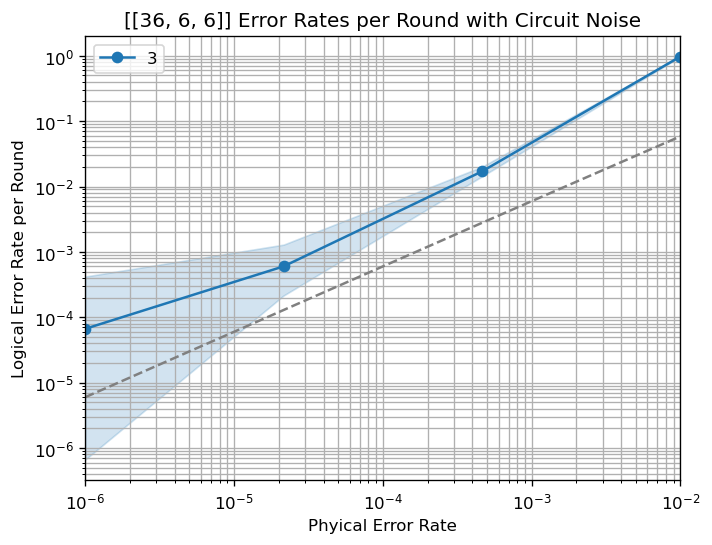

In [25]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=results,
    x_func=lambda stat: stat.json_metadata['p'],
    group_func=lambda stat: stat.json_metadata['rounds'],
    failure_units_per_shot_func=lambda stat: stat.json_metadata['rounds'],
)
physical_error_rates = 1 - (1 - PS)**benchmarker.num_logicals
ax.loglog(PS, physical_error_rates, color='gray', linestyle='--')
# ax.set_ylim(5e-3, 5e-2)
ax.set_xlim(PS[0], PS[-1])
ax.loglog()
ax.set_title(f"{CODE_NAME} Error Rates per Round with Circuit Noise")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Round")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger